# BE1- Elasticité bidimensionnelle 

*Léo Parnotte, Laura Souverin*

---

## Présentation du problème 

### Situation observée 

Nous étudions une plaque rectangulaire 2D constituée d'un matériau homogène et isotrope. Le bord gauche est encastré et une force de traction $f_{vx}​$ est appliquée horizontalement.

On travaille en petites perturbations et en élasticité linéaire. De plus, on adopte le modèle des contraintes planes, c'est à dire qu'on considère que les contraintes s'exercent uniquement dans le plan de la plaque. 


### Éléments finis 
On part de la *formulation variationelle* du problème d'élasticité : 

Trouver $u \in V_0$ tel que $a(u,v)=L(v)$,  $\forall v \in V_0$ avec : 
* $a(u,v) = \int_{\Omega} \epsilon(v) : H : \epsilon(u) \, d\Omega$ (Énergie de déformation interne)
* $L(v) = \int_{\Omega} f_v \cdot v \, d\Omega + \int_{\Gamma_F} f_s \cdot v \, d\Gamma$ 
* $H$ l'opérateur de Hooke

On discrétise ce problème en cherchant une solution approchée $u_h$ dans un espace de dimension finie $V_{0h}$ :

Trouver $u_h \in V_{0h}$ tel que $a(u_h, v_h) = L(v_h), \forall v_h \in V_{0h}$

En décomposant $u_h$ sur une base de fonctions de forme $N_i$ telles que $u_h(x) = \sum_{i=0}^{n} u_i N_i(x)$, le problème se ramène à la résolution d'un système linéaire : 

$$\sum_{j=0}^{n} a(N_i, N_j) u_j = L(N_i)$$


ce qui s'écrit, sous forme matricielle : 
$$ KU=F$$
* **$K$** est la **Matrice de rigidité**.
* **$F$** est le vecteur des charges nodales.
* **$U$** est le vecteur des déplacements inconnus aux nœuds.
### Triangles P1 de Lagrange

Pour la discrétisation spatiale, on utilise des *triangles P1 de Lagrange*. La solution est représentée par des fonctions de base linéaires par morceaux, définies sur chaque triangle du maillage.

Les équations des fonctions de forme associées sont :

$$
\begin{cases}
N_1(x, y) = \frac{1}{2|T_e|} \left( (x_2 y_3 - x_3 y_2) + (y_2 - y_3) x + (x_3 - x_2) y \right) \\
N_2(x, y) = \frac{1}{2|T_e|} \left( (x_3 y_1 - x_1 y_3) + (y_3 - y_1) x + (x_1 - x_3) y \right) \\
N_3(x, y) = \frac{1}{2|T_e|} \left( (x_1 y_2 - x_2 y_1) + (y_1 - y_2) x + (x_2 - x_1) y \right)
\end{cases}
$$

Avec $|T_e|$ l'aire de l'élément, 

$$ |T_e|=\frac{1}{2}|(x_2-x_1)(y_3-y_1)-(y_2-y_1)(x_3-x_1)|$$

et $(x_1,y_1)$, $(x_2,y_2)$, $(x_3,y_3)$ les coordonées des sommets des triangles. 


## Travail demandé 

###  **Partie 1** Calcul des déplacements par la méthode des éléments finis

On commence par définir les variables globales : 

In [21]:
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.io 
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as tri 

In [22]:
maille = 1  # Choix du maillage 1 (gros),2 (plus fin) ,3 (encore plus fin) ou 4 (trou)

# Proprietes mecaniques
E = 1000 # Young's modulus  
v = 0.3  # Poisson's coefficient

# Forces (densité surfacique ici)
fvx = 100          
fvy = 0 
fv = np.array([fvx,fvy])


In [23]:
# lécture du maillage
if maille == 1:
    mat = scipy.io.loadmat('./maillage_1.mat')
elif maille ==2:
    mat = scipy.io.loadmat('./maillage_2.mat')
elif maille ==3:
    mat = scipy.io.loadmat('./maillage_3.mat')
elif maille ==4:
    mat = scipy.io.loadmat('./maillage_trou.mat')
else:
    raise ValueError('Maille 1,2,3 ou 4 ')

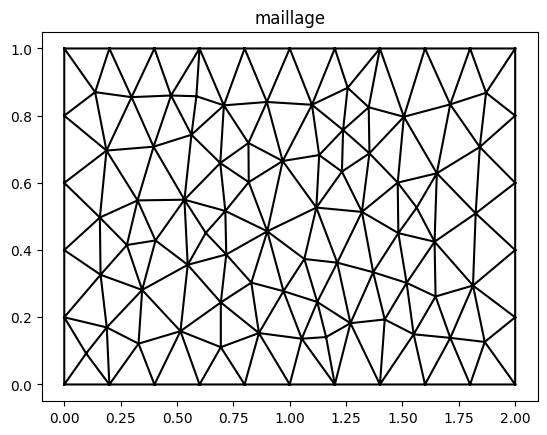

In [24]:
# coordonnes des noeuds  
X = mat['p'].T  # chaque ligne est un noeud, la premiere colonne x la deuxième y 

# table de connectivite
C = mat['t'].T[:,:-1] -1   #nous donne quels noeuds forment quels triangle -> si la premiere ligne est [0,3,5] ça veut dire que le premier triangle est formé des noeuds 0,3,5

# nombre de noeuds du maillage
n_nodes = X.shape[0] # nombre de lignes 

# nombre d'elements du maillage
n_elems = C.shape[0]  # nombre de ligne -> chque ligne un élément

# Nombre de noeuds par element
n_nodes_elem = 3 # ce sont des triangles P1

# Nombre de ddl par element
ndofe= 2*n_nodes_elem # champ vectoriel en 2D chaque sommet peut bouger selon 2 directions 

# Nombre de ddl dans tout le domaine  
ndof = 2*n_nodes # champ vectoriel en 2D


# dimensions de la plaque 
xmin =  np.min(X[:,0])
xmax =  np.max(X[:,0])
ymin =  np.min(X[:,1])
ymax =  np.max(X[:,1])
# vérifier dimensions de la plaque [0,2]x[0,1]

# affichage du maillage
Initial_triangulation =  tri.Triangulation(X[:,0],X[:,1],C)
plt.figure(0)
plt.triplot(Initial_triangulation, color = 'black')
plt.title("maillage")
plt.show()


#### Q1) Implémentation de la Matrice de Rigidité

Pour cette étape, nous implémentons la fonction `fun_tri_P1_lag`. Celle-ci prend en entrée les coordonnées du point d'évaluation ainsi que les coordonnées des trois sommets du triangle associé. Elle renvoie un tableau contenant les valeurs des trois fonctions de forme de Lagrange ($N_i$) ainsi que leurs dérivées spatiales. 


Nous implémentons également la fonction `GetBe`. Elle prend en entrée les dérivées des fonctions de Lagrange et construit la matrice $[B_e]$. Cette matrice permet de relier les déformations $\{\varepsilon\}$ aux déplacements nodaux $\{u_e\}$ r :

$$
[B_e] = \begin{bmatrix} 
\frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial x} & \frac{\partial N_3}{\partial x} & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{\partial N_1}{\partial y} & \frac{\partial N_2}{\partial y} & \frac{\partial N_3}{\partial y} \\
\frac{\partial N_1}{\partial y} & \frac{\partial N_2}{\partial y} & \frac{\partial N_3}{\partial y} & \frac{\partial N_1}{\partial x} & \frac{\partial N_2}{\partial x} & \frac{\partial N_3}{\partial x}
\end{bmatrix}
$$


In [25]:
def fun_tri_P1_lag(x,y,x_nodes,y_nodes):
    # x,y -> point d'évaluation
    # x_nodes -> tableau 1D numpy avec abscisses des noeuds (ceux qui faut)
    # y_nodes -> tableau 1D numpy avec ordonnées des noeuds (ceux qui faut)
    #calcoul dou Te
    Te=0.5*np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0])-(y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))

    N1=(x_nodes[1]*y_nodes[2]-x_nodes[2]*y_nodes[1])+(y_nodes[1]-y_nodes[2])*x+(x_nodes[2]-x_nodes[1])*y
    N2=(x_nodes[2]*y_nodes[0]-x_nodes[0]*y_nodes[2])+(y_nodes[2]-y_nodes[0])*x+(x_nodes[0]-x_nodes[2])*y
    N3=(x_nodes[0]*y_nodes[1]-x_nodes[1]*y_nodes[0])+(y_nodes[0]-y_nodes[1])*x+(x_nodes[1]-x_nodes[0])*y
    
    N = 1/(2*Te)*np.array((N1,N2,N3))
    
    # calcoul da dérivé en x
    dxN1=(y_nodes[1]-y_nodes[2])
    dxN2=(y_nodes[2]-y_nodes[0])
    dxN3=(y_nodes[0]-y_nodes[1])
    
    dNdx = 1/(2*Te)*np.array((dxN1,dxN2,dxN3))
    
    #calcoul da dérivée en y
    dyN1=(x_nodes[2]-x_nodes[1])
    dyN2=(x_nodes[0]-x_nodes[2])
    dyN3=(x_nodes[1]-x_nodes[0])
    
    dNdy = 1/(2*Te)*np.array((dyN1,dyN2,dyN3))
    
    return [N,dNdx,dNdy]
    # N = [N1(x,y),N2(..),N3(..)]-> tableau 1D numpy avec valeur des 3 funs au point d'éval
    # dNdx -> idem avec dérivée par rapport à x des funs
    # dNdy -> idem avec dérivée par rapport à y des funs


def GetBe(dNdx,dNdy):
    # dNdx=[dN1dx(x,y),dN2dx(x,y),dN3dx(x,y)] -> tableau 1D numpy avec valeur à un certain point d'éval
    
    Be = np.zeros((n_nodes_elem,ndofe))
    Be[0,0:3]=dNdx
    Be[1,3:]=dNdy
    Be[2,0:3]=dNdy
    Be[2,3:]=dNdx
    
    return Be
    # Be : matrice élémentaire lien déformation - déplacement (evaluee à un certain point)

    

On assemble ensuite la matrice de rigidité. Chacun de ses éléments représentent la contribution locale du triangle à la raideur totale de la structure. 

Pour chaque élément (triangle) $T_e$, on définit la matrice de rigidité élémentaire $[k_e]$ par l'intégrale sur le domaine de l'élément :

$$[k_e] = \int_{T_e} [Be]^T [D] [B] \, d\Omega$$

Où :
* **$[H]$** est la matrice de comportement (ou matrice d'élasticité), qui contient les constantes du matériau (Module de Young $E$ et coefficient de Poisson $\nu$).

Dans le cas des triangles $P1$, la matrice $[B]$ est constante sur l'élément. L'intégrale se simplifie donc en un produit simple avec l'aire $|T_e|$ :
$$[k_e] = [B]^T [H] [B] \cdot |T_e| $$



In [27]:
# on définit la matrice de comportement
H = np.array([[E/(1-v**2),v*E/(1-v**2),0],
              [v*E/(1-v**2),E/(1-v**2),0],
             [0,0,E/(2*(1+v))]])

    
# initialisation de la matrice de rigiditié 
K = np.zeros((ndof,ndof)) 

# Boucle sur les éléments

for e in range(n_elems): # pour chaque triangle
    
    # coordonnes des noeuds de l'element e   
    numero = C[e,:] # on prend les noeud correspondant à l'élément e 
    x1,y1 = X[numero[0],:] # on prend leurs coordonées 
    x2,y2 = X[numero[1],:]
    x3,y3 = X[numero[2],:]
    
    x_nodes = np.array([x1,x2,x3]) # on regrouppe les coordonnées 
    y_nodes = np.array([y1,y2,y3])
    
    x,y = (0,0) 
    
    N,dNdx,dNdy = fun_tri_P1_lag(x, y, x_nodes, y_nodes) # on calcule les dérivées (peu importe le point)
    
    Be = GetBe(dNdx, dNdy) # on crée la matrice Be
    
    Te=0.5*np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0])-(y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))
    Ke = Te*(Be.T@H@Be) #on calcule l'élement e de la matrice de rigidité
     
    # Assemblage des contributions élémentaires
    # un même noeud appartient à plusieurs triangles 
    for i in range(n_nodes_elem):# pour chaque noeud du triangle 
        for j in range(n_nodes_elem):
            K[C[e,i],C[e,j]] += Ke[i,j]  
            K[C[e,i]+n_nodes,C[e,j]] += Ke[i+n_nodes_elem,j]
            K[C[e,i],C[e,j]+n_nodes] += Ke[i,j+n_nodes_elem]
            K[C[e,i]+n_nodes,C[e,j]+n_nodes] += Ke[i+n_nodes_elem,j+n_nodes_elem]


#### Q2) Calcul du second membre 

Dans cette partie, nous cherchons à calculer le second membre $F$.

Pur ceci, nous implémentons la fonction *GetNe*, qui renvoie la matrice $N_e$, qui a pour forme : 


$$
[N_e] = \begin{bmatrix} 
N_1^e(x,y) & N_2^e(x,y) & N_3^e(x,y) & 0 & 0& 0 \\
& 0 & 0& 0 & N_1^e(x,y) & N_2^e(x,y) & N_3^e(x,y)
\end{bmatrix}
$$

Dans le calcul du second membre, elle intervient pour transformer les forces volumiques $f_{vx}$ en forces nodales. Mathématiquement, la contribution d'un élément au vecteur force est donnée par :
$$\{F_e\} = \int_{T_e} [N_e]^T \{f_{vx}\} \, d T_e$$

Ainsi, la matrice $[N_e]$ sert à distribuer les forces appliquées sur la surface du triangle directement sur ses trois sommets.


In [30]:
def GetNe(N): # prend le vecteur contenant les valeurs des fonctions N_i
    
    Ne_matrix=np.zeros((n_nodes_elem-1,ndofe)) #lignes : nombre de noeuds par élément -1, colonnes : nombre de degrés de libertés par éléments
    Ne_matrix[0,0:3]=N
    Ne_matrix[1,3:]=N
    
    return Ne_matrix

ON assemble maintenant la matrice du second membre $F$. 

In [31]:
F = np.zeros(ndof) # on initialise le vecteur à 0

for e in range(n_elems):
    numero= C[e,:] # on prend la ligne correspondant à l'élément e 

    x1, y1 = X[numero[0],:]# on prend les coordonnées de chaque noeud 
    x2, y2 = X[numero[1],:]
    x3, y3 = X[numero[2],:]
    
    x_nodes = np.array([x1, x2, x3])
    y_nodes = np.array([y1, y2, y3])

    Te = 0.5 * np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0])- (y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))
    N1,dNdx,dNdy = fun_tri_P1_lag(x1, y1, x_nodes, y_nodes)
    N2,dNdx,dNdy = fun_tri_P1_lag(x2, y2, x_nodes, y_nodes)
    N3,dNdx,dNdy = fun_tri_P1_lag(x3, y3, x_nodes, y_nodes) # on caclule la fonction pour chaque noeud 
    
    Fe = Te * (GetNe(N1).T @ fv + GetNe(N2).T @ fv + GetNe(N3).T @ fv) # on calcule la valeur de Fe
   
    for i in range(len(numero)):# on complète F
        F[numero[i]] += Fe[i] 
F[numero[i]] += Fe[i]

#### Q3) Conditions de Dirichlet 
Le bord de notre plaque est encastrée en $x=0$. Ainsi, pour chaque noeud au bord, le déplacement doit être nul. Pour appliquer cette condition, et faire en sorte que le système soit singulier, on modifie $K$ et $F$.

In [ ]:
for n in range(n_nodes):# on boucle sur l'ensemble des noeuds de la plaque

    x = X[n,0] # on récupère la coordonée en x de ce noeud 

    if x< 1e-10: # s'il est =0 (avec une sécurité pour éviter les erreurs numériques )
        i = n # pour le mouvement horizontal
        K[i,:] = 0 # on "isole" le point considéré 
        K[:,i] = 0 # on "isole" le point considéré 
        K[i,i] = 1 # quand on devra résoudre, on aura 1*ui =0 -> déplacement =0
        F[i] = 0


        i = n+n_nodes # pour le mouvement vertical 
        K[i,:] = 0 #idem
        K[:,i] = 0
        K[i,i] = 1
        F[i] = 0


#### Q4) Résolution du système linéaire 

On résout maintenant le système linéaire afin de visualiser la déformation du système. On modifie $\nu$ pour visualiser l'effet poisson.  

On visualise la solution pour $\nu=0.3$ et $\nu=0$

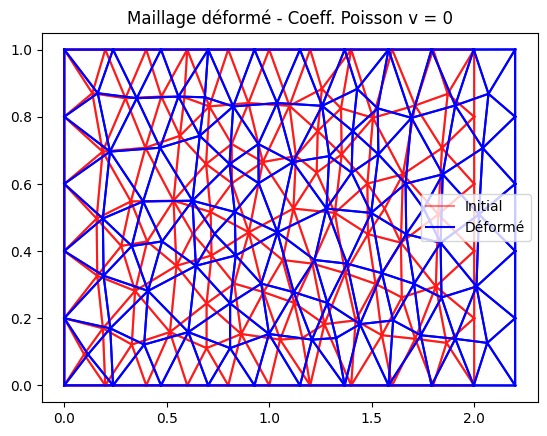

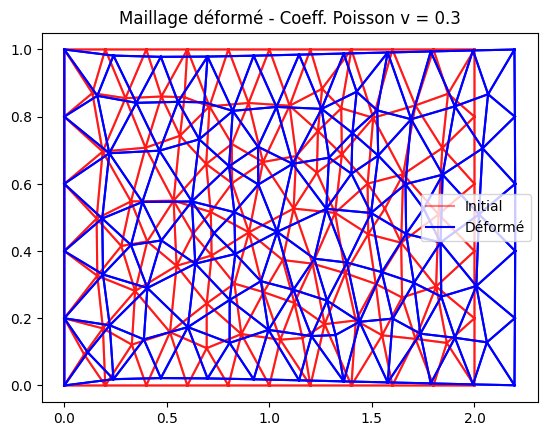

In [47]:
# Boucle sur les deux coefficients de Poisson
for v_val in [0, 0.3]:
    v = v_val # On affecte la valeur de la boucle à ta variable v

    H = np.array([[E/(1-v**2),v*E/(1-v**2),0],
                  [v*E/(1-v**2),E/(1-v**2),0],
                 [0,0,E/(2*(1+v))]])

    # initialisation de la matrice de rigiditié 
    K = np.zeros((ndof,ndof)) 

    # Boucle sur les éléments
    for e in range(n_elems): 
        numero = C[e,:] 
        x1,y1 = X[numero[0],:] 
        x2,y2 = X[numero[1],:]
        x3,y3 = X[numero[2],:]
        
        x_nodes = np.array([x1,x2,x3]) 
        y_nodes = np.array([y1,y2,y3])
        
        x,y = (0,0) 
        N,dNdx,dNdy = fun_tri_P1_lag(x, y, x_nodes, y_nodes) 
        
        Be = GetBe(dNdx, dNdy) 
        
        Te=0.5*np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0])-(y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))
        Ke = Te*(Be.T@H@Be) 
         
        for i in range(n_nodes_elem):
            for j in range(n_nodes_elem):
                K[C[e,i],C[e,j]] += Ke[i,j]  
                K[C[e,i]+n_nodes,C[e,j]] += Ke[i+n_nodes_elem,j]
                K[C[e,i],C[e,j]+n_nodes] += Ke[i,j+n_nodes_elem]
                K[C[e,i]+n_nodes,C[e,j]+n_nodes] += Ke[i+n_nodes_elem,j+n_nodes_elem]

    F = np.zeros(ndof) 

    for e in range(n_elems):
        numero= C[e,:] 
        x1, y1 = X[numero[0],:]
        x2, y2 = X[numero[1],:]
        x3, y3 = X[numero[2],:]
        
        x_nodes = np.array([x1, x2, x3])
        y_nodes = np.array([y1, y2, y3])

        Te = 0.5 * np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0])- (y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))
        N1,_,_ = fun_tri_P1_lag(x1, y1, x_nodes, y_nodes)
        N2,_,_ = fun_tri_P1_lag(x2, y2, x_nodes, y_nodes)
        N3,_,_ = fun_tri_P1_lag(x3, y3, x_nodes, y_nodes) 
        
        Fe = (Te/3) * (GetNe(N1).T @ fv + GetNe(N2).T @ fv + GetNe(N3).T @ fv) 
       
        for i in range(len(numero)):
            F[numero[i]] += Fe[i] 
            F[numero[i]+n_nodes] += Fe[i+n_nodes_elem]

    for n in range(n_nodes):
        x_coord = X[n,0] 
        if x_coord < 1e-10: 
            i = n 
            K[i,:] = 0 
            K[:,i] = 0 
            K[i,i] = 1 
            F[i] = 0

            i = n+n_nodes 
            K[i,:] = 0 
            K[:,i] = 0
            K[i,i] = 1
            F[i] = 0

    U = np.linalg.solve(K,F)

    # Calcul des coordonnes des noeuds apres deformation
    x_new = X[:,0] + U[:n_nodes]
    y_new = X[:,1] + U[n_nodes:]

    # Affichage
    plt.figure() # Crée une nouvelle fenêtre pour chaque v
    Deformed_triangulation = tri.Triangulation(x_new, y_new, C)
    plt.triplot(Initial_triangulation, color = 'red', alpha=0.8)
    plt.triplot(Deformed_triangulation, color = 'blue')
    plt.triplot(Initial_triangulation, color='red', alpha=0.5, label='Initial')
    plt.triplot(Deformed_triangulation, color='blue', label='Déformé')
    plt.legend()
    plt.title(f"Maillage déformé - Coeff. Poisson v = {v}")

plt.show() # Bloque l'affichage pour garder les deux fenêtres ouvertes

Le *coefficient de Poisson* est une constante adimensionnelle mesurant la déformation d'un matériau solide perpendiculairement à la direction de l'effort appliqué. Dans notre cas, il mesure la déformation selon l'axe vertical. 

Dans le cas $\nu=0$ on observe que la plaque s'allonge horizontalement sous l'effet de la traction, mais sa hauteur reste inchangée. Nous nous sommes placés dans le cas d'un matériau qui ne se contracte pas quand on l'étire. 

Dans le cas $\nu=0.3$ on observe l'allongement horizontal ainsi qu'un rétrécissement vertical.


### **Partie 2** Post-traitement : contraintes de Von Mises

On cherche à observer la contrainte de Von Mises dans la plaque. Celle ci est une norme du tenseur de contrainte qui se définit comme : 

$$\sigma_{VM} = \sqrt{\sigma_{xx}^2 + \sigma_{yy}^2 + 3\sigma_{xy}^2 - \sigma_{xx}\sigma_{yy}}$$
Où, 
* $ \sigma_{xx}$ correspond à la contrainte selon l'axe horizontal. Elle est positive si le matériau est étiré (traction) et négative s'il est écrasé (compression).
* $ \sigma_{xy} $ correspond à la contrainte selon l'axe vertical.
* $ \sigma_{xy} $ correspond à la contraintede cisaillement

La contrainte de Von Mises permet d'étudier un état de contrainte complexe grâce une valeur unique. 

On fait une boucle, afin de visualiser pour chaque maillage les contraintes de Von Mises. On utilise le code fourni dans le TP. 


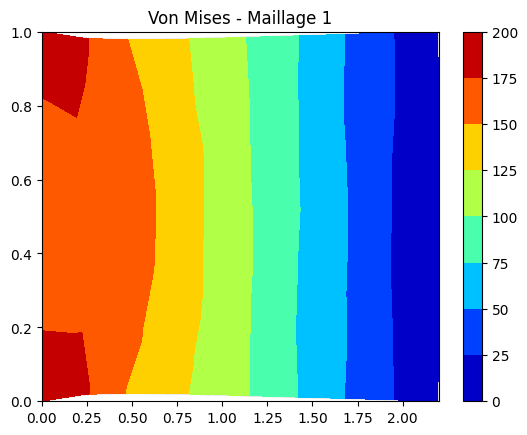

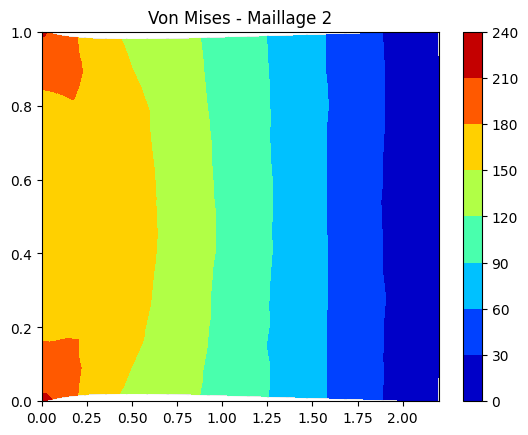

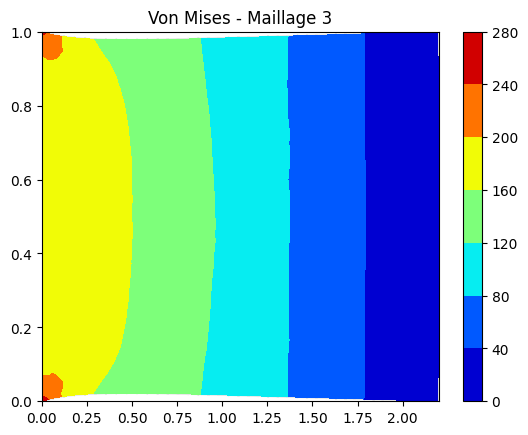

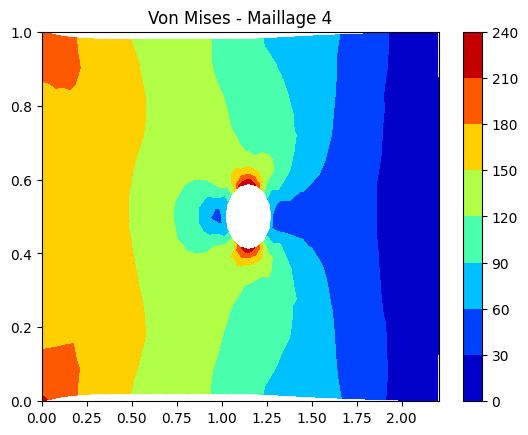

In [49]:
v = 0.3

for maille in [1, 2, 3, 4]:
    
    if maille == 1:
        mat = scipy.io.loadmat('./maillage_1.mat')
    elif maille == 2:
        mat = scipy.io.loadmat('./maillage_2.mat')
    elif maille == 3:
        mat = scipy.io.loadmat('./maillage_3.mat')
    elif maille == 4:
        mat = scipy.io.loadmat('./maillage_trou.mat')

    # Ton code d'importation
    X = mat['p'].T  
    C = mat['t'].T[:,:-1] - 1   
    n_nodes = X.shape[0] 
    n_elems = C.shape[0] 
    n_nodes_elem = 3 
    ndofe = 2*n_nodes_elem 
    ndof = 2*n_nodes 

    # --- RÉSOLUTION (Ton code) ---
    H = np.array([[E/(1-v**2),v*E/(1-v**2),0],
                  [v*E/(1-v**2),E/(1-v**2),0],
                  [0,0,E/(2*(1+v))]])

    K = np.zeros((ndof,ndof)) 

    for e in range(n_elems): 
        numero = C[e,:] 
        x1,y1 = X[numero[0],:] 
        x2,y2 = X[numero[1],:]
        x3,y3 = X[numero[2],:]
        x_nodes = np.array([x1,x2,x3]); y_nodes = np.array([y1,y2,y3])
        
        N,dNdx,dNdy = fun_tri_P1_lag(0, 0, x_nodes, y_nodes) 
        Be = GetBe(dNdx, dNdy) 
        Te = 0.5*np.abs((x2-x1)*(y3-y1)-(y2-y1)*(x3-x1))
        Ke = Te*(Be.T@H@Be) 
         
        for i in range(n_nodes_elem):
            for j in range(n_nodes_elem):
                K[C[e,i],C[e,j]] += Ke[i,j]  
                K[C[e,i]+n_nodes,C[e,j]] += Ke[i+n_nodes_elem,j]
                K[C[e,i],C[e,j]+n_nodes] += Ke[i,j+n_nodes_elem]
                K[C[e,i]+n_nodes,C[e,j]+n_nodes] += Ke[i+n_nodes_elem,j+n_nodes_elem]

    F = np.zeros(ndof) 
    for e in range(n_elems):
        numero = C[e,:]; x_nodes = X[numero,0]; y_nodes = X[numero,1]
        Te = 0.5 * np.abs((x_nodes[1]-x_nodes[0])*(y_nodes[2]-y_nodes[0]) - (y_nodes[1]-y_nodes[0])*(x_nodes[2]-x_nodes[0]))
        N1,_,_ = fun_tri_P1_lag(x_nodes[0], y_nodes[0], x_nodes, y_nodes)
        N2,_,_ = fun_tri_P1_lag(x_nodes[1], y_nodes[1], x_nodes, y_nodes)
        N3,_,_ = fun_tri_P1_lag(x_nodes[2], y_nodes[2], x_nodes, y_nodes) 
        Fe = (Te/3) * (GetNe(N1).T @ fv + GetNe(N2).T @ fv + GetNe(N3).T @ fv) 
        for i in range(len(numero)):
            F[numero[i]] += Fe[i] 
            F[numero[i]+n_nodes] += Fe[i+n_nodes_elem]

    for n in range(n_nodes):
        if X[n,0] < 1e-10: 
            K[n,:], K[:,n], K[n,n], F[n] = 0, 0, 1, 0
            K[n+n_nodes,:], K[:,n+n_nodes], K[n+n_nodes,n+n_nodes], F[n+n_nodes] = 0, 0, 1, 0

    U = np.linalg.solve(K,F)

    T_surf = np.zeros(n_nodes)
    SVM = np.zeros(n_nodes)

    for e in range(n_elems):
        x_nodes = X[C[e,:],0]; y_nodes = X[C[e,:],1]
        x1=x_nodes[0]; x2=x_nodes[1]; x3=x_nodes[2]
        y1=y_nodes[0]; y2=y_nodes[1]; y3=y_nodes[2]
        Te = 0.5*np.abs((x2-x1)*(y3-y1)-(y2-y1)*(x3-x1))
        
        [Nm,dNmdx,dNmdy] = fun_tri_P1_lag(x1,y1,x_nodes,y_nodes)
        Be = GetBe(dNmdx,dNmdy)
        Ue = np.r_[U[C[e,:]],U[C[e,:]+n_nodes]] # Déplacements de l'élément e
        
        sigma = H.dot(Be.dot(Ue))
        svm = (sigma[0]**2+sigma[1]**2+3*sigma[2]**2-sigma[0]*sigma[1])**0.5 
        
        for i in range(n_nodes_elem):
            T_surf[C[e,i]] += Te
            SVM[C[e,i]] += Te*svm

    SVM = SVM/T_surf # Moyenne aux noeuds

    # --- AFFICHAGE ---
    x_new = X[:,0] + U[:n_nodes]
    y_new = X[:,1] + U[n_nodes:]
    
    plt.figure() # Ouvre une nouvelle fenêtre
    t_plot = mtri.Triangulation(x_new, y_new, C)
    plt.triplot(t_plot, color='black', alpha=0.1)
    plt.tricontourf(t_plot, SVM, cmap='jet')
    plt.colorbar()
    plt.title(f'Von Mises - Maillage {maille}')

plt.show()